# Plant Disease Classifier

## Exploratory Data Analysis (EDA)

How many classes are there? What are they? And the size of the images and are they all the same?.

In [1]:
import os
path = "data/PlantVillage"
classes = os.listdir(path + "/train")
print(len(classes)-1)

37


In [2]:
# Number of images in each class
images_per_class = {}
for class_name in classes:
    class_path = os.path.join(path, "train", class_name)
    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)
        images_per_class[class_name] = image_files

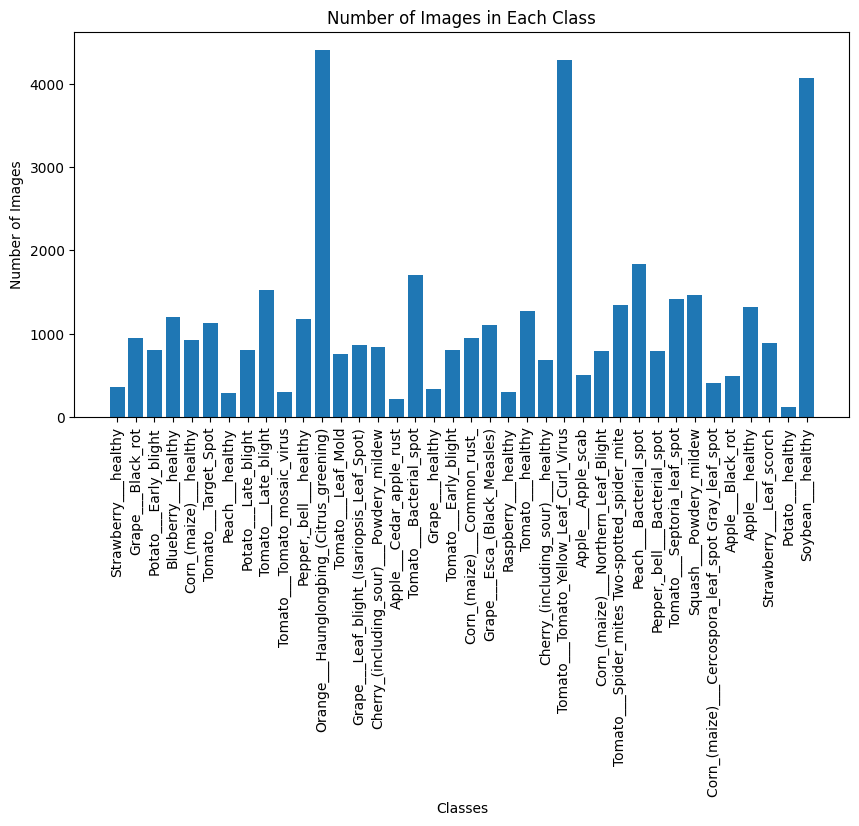

In [3]:
# Plot the number of images in each class
import matplotlib.pyplot as plt
images_counts = []
for k in images_per_class.keys():
    images_counts.append(len(images_per_class[k]))
plt.figure(figsize=(10, 5))
plt.bar(images_per_class.keys(), images_counts)
plt.xlabel("Classes")
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Number of Images in Each Class")
plt.show()

In [4]:
all_images = [
    os.path.join(path, "train", class_name, filename)
    for class_name, filenames in images_per_class.items()
    for filename in filenames
]
len(all_images)

43444

In [5]:
from PIL import Image
from collections import Counter

shapes = [Image.open(p).size for p in all_images]  # (width, height)
print(Counter(shapes))
print("all same:", len(set(shapes)) == 1)

Counter({(256, 256): 43444})
all same: True


Plot the an image of each class

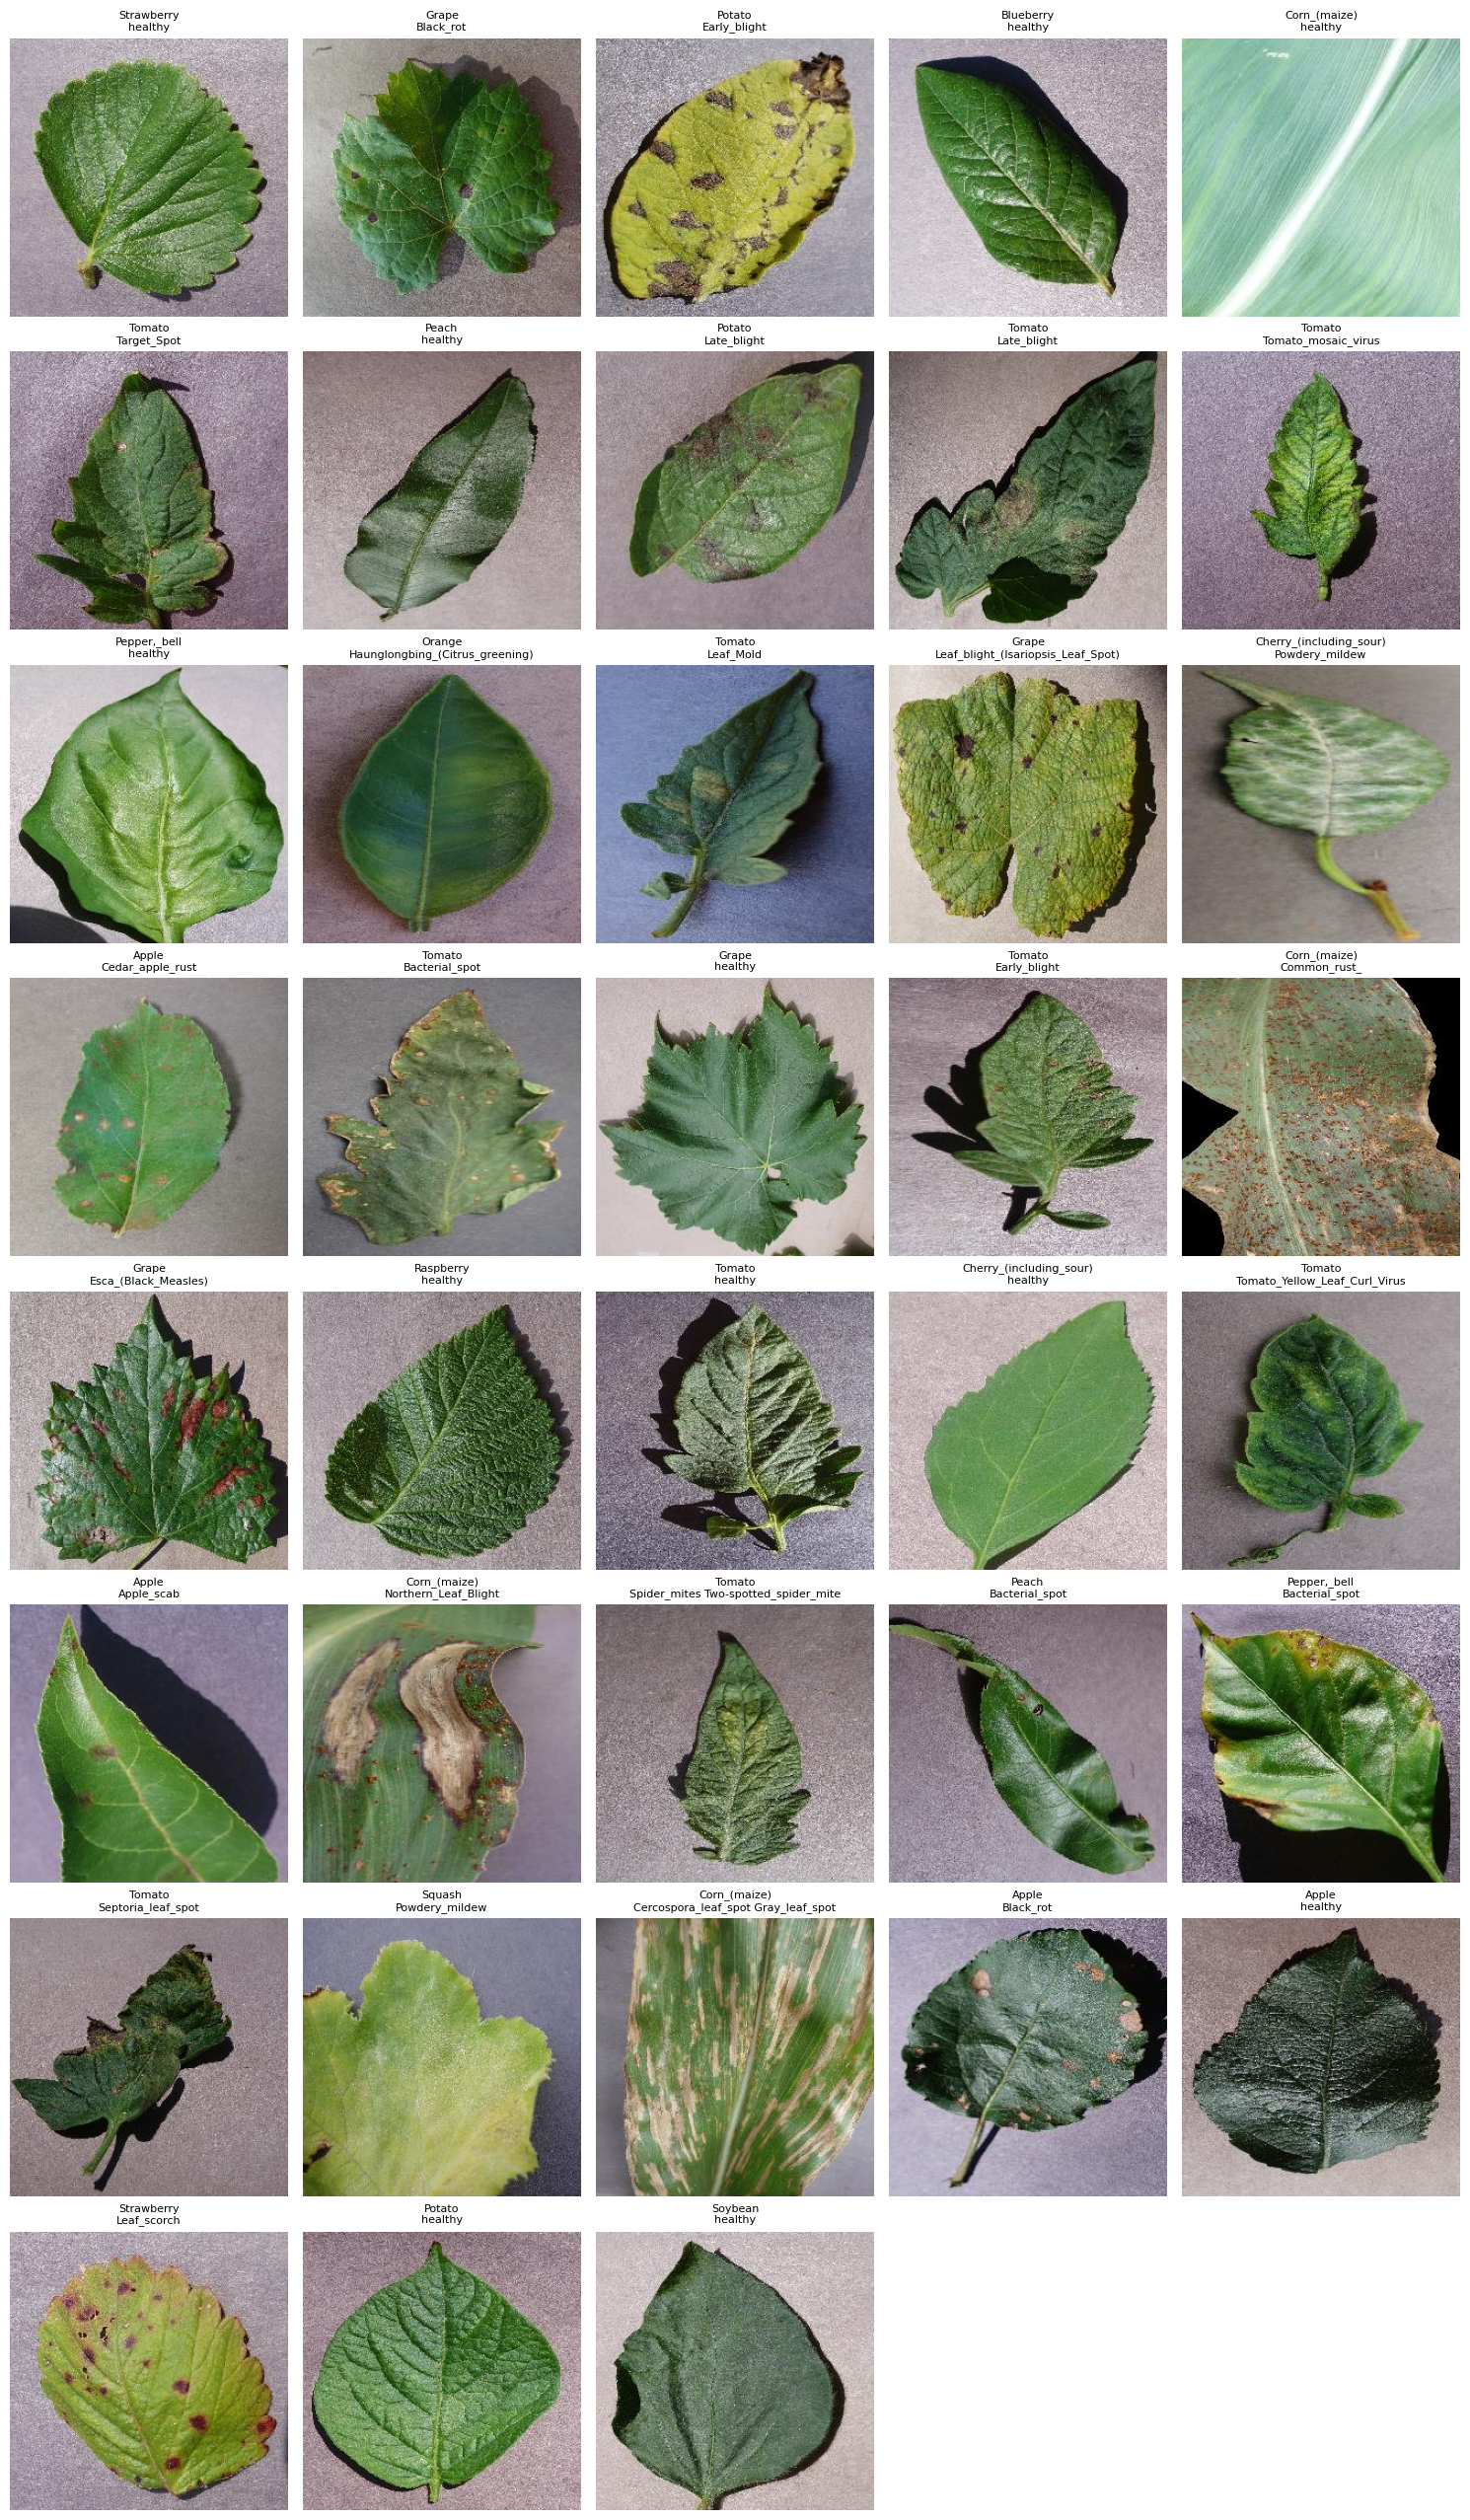

In [6]:
# Plot an image from each class
import math

n_classes = len(images_per_class)
cols = 5
rows = math.ceil(n_classes / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.2))
axes = axes.flatten()

for i, (key, value) in enumerate(images_per_class.items()):
    img = Image.open(os.path.join(path, "train", key, value[0]))
    axes[i].imshow(img)
    axes[i].set_title(key.replace("___", "\n"), fontsize=8)
    axes[i].axis("off")

# Hide any unused subplots
for ax in axes[n_classes:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Build the dataset

In [7]:
import tensorflow as tf
TRAIN_DIR = "data/PlantVillage/train"
VAL_DIR = "data/PlantVillage/val"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
  TRAIN_DIR,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  label_mode="categorical",
  shuffle=True,
  seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  VAL_DIR,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE,
  label_mode="categorical",
  shuffle=False,
)

class_names = train_ds.class_names
print(len(class_names), class_names[:5])

/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
38 ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


Normalization (0-255 -> 0-1)

In [8]:
normalize = tf.keras.layers.Rescaling(1.0/255)
AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, training=False):
  ds = ds.unbatch()                                                                # unbatch the dataset
  ds = ds.map(lambda x, y: (tf.cast(x, tf.uint8), y), num_parallel_calls=AUTOTUNE) # unit8
  ds = ds.cache()                  
  if training:
    ds = ds.shuffle(1000, seed=42)                                                 # remix every epoch
  ds = ds.batch(BATCH_SIZE)
  ds = ds.map(lambda x, y: (normalize(x), y), num_parallel_calls=AUTOTUNE)
  return ds.prefetch(AUTOTUNE)                                                     # Prepare next batch while training on GPU

train_ds = prepare(train_ds, training=True)
val_ds = prepare(val_ds)

In [9]:
# Validate the preprocess step
import time
def time_pass(ds, name):
  start = time.time()
  for _ in ds:
    pass
  print(f"{name}: {time.time() - start:.1f}s")
  
time_pass(train_ds, "pass 1 (filling cache)")
time_pass(train_ds, "pass 2 (reading from cache)")

2026-10-05 19:13:46.948427: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


pass 1 (filling cache): 3.8s
pass 2 (reading from cache): 0.6s


2026-10-05 19:13:47.587527: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
# Tensorflow version & CPU devices
print("TensorFlow version:", tf.__version__)
print("CPU devices:", tf.config.list_physical_devices())

TensorFlow version: 2.20.0
CPU devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


Baseline CNN

In [11]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(128,128,3))
conv1 = Conv2D(32, kernel_size=(3,3), activation='relu', padding='same')(inputs)
maxpooling1 = MaxPooling2D(pool_size=(3,3))(conv1)
conv2 = Conv2D(64, kernel_size=(3,3), activation='relu', padding='same')(maxpooling1)
maxpooling2 = MaxPooling2D(pool_size=(3,3))(conv2)
conv3 = Conv2D(128, kernel_size=(3,3), activation='relu', padding='same')(maxpooling2)
maxpooling3 = MaxPooling2D(pool_size=(3,3))(conv3)
x = Flatten()(maxpooling3)
x = Dense(128, activation='relu')(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 42, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 42, 42, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 360,422 (1.37 MB)

 Trainable params: 360,422 (1.37 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
  optimizer='adam', 
  loss='categorical_crossentropy', 
  metrics=['accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
        ]
  )

Sanity Checks Before Training

In [13]:
import math
loss_prob = math.log(len(class_names))
loss_prob

3.6375861597263857

In [14]:
images, labels = next(iter(train_ds))
result = model.evaluate(images, labels, return_dict=True, verbose=0)
print(result['loss'])

3.648402214050293


Try to overfit to one batch of images

In [15]:
history = model.fit(images, labels, epochs=50, verbose=0)
print(f"Started Loss: {history.history['loss'][0]}")
print(f"Ended Loss: {history.history['loss'][-1]}")

Started Loss: 3.648402214050293
Ended Loss: 0.010718608275055885


Reconstruct and compile the models

In [16]:
inputs = Input(shape=(128,128,3))
conv1 = Conv2D(32, kernel_size=(3,3), activation='relu', padding='same')(inputs)
maxpooling1 = MaxPooling2D(pool_size=(3,3))(conv1)
conv2 = Conv2D(64, kernel_size=(3,3), activation='relu', padding='same')(maxpooling1)
maxpooling2 = MaxPooling2D(pool_size=(3,3))(conv2)
conv3 = Conv2D(128, kernel_size=(3,3), activation='relu', padding='same')(maxpooling2)
maxpooling3 = MaxPooling2D(pool_size=(3,3))(conv3)
x = Flatten()(maxpooling3)
x = Dense(128, activation='relu')(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()

model.compile(
  optimizer='adam', 
  loss='categorical_crossentropy', 
  metrics=['accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
        ]
  )

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 42, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 42, 42, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 360,422 (1.37 MB)

 Trainable params: 360,422 (1.37 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
small_train = train_ds.take(100)   # batch 100 = ~3,200 images
small_val   = val_ds.take(30)

history = model.fit(small_train, validation_data=small_val, epochs=2)

Epoch 1/2
     99/Unknown 6s 50ms/step - accuracy: 0.1298 - loss: 3.3468 - precision: 0.3389 - recall: 0.0084

/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.1309 - loss: 3.3426 - precision: 0.3460 - recall: 0.0089 - val_accuracy: 0.0125 - val_loss: 3.5278 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/2
  2/100 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.2891 - loss: 2.7369 - precision: 0.7167 - recall: 0.1250  

2026-10-05 19:16:48.069000: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-10-05 19:16:48.082243: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.3262 - loss: 2.5456 - precision: 0.7475 - recall: 0.1469 - val_accuracy: 0.1292 - val_loss: 3.2612 - val_precision: 0.0103 - val_recall: 0.0010


2026-10-05 19:16:53.793977: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Reconstruct the model again

In [18]:
inputs = Input(shape=(128,128,3))
conv1 = Conv2D(32, kernel_size=(3,3), activation='relu', padding='same')(inputs)
maxpooling1 = MaxPooling2D(pool_size=(3,3))(conv1)
conv2 = Conv2D(64, kernel_size=(3,3), activation='relu', padding='same')(maxpooling1)
maxpooling2 = MaxPooling2D(pool_size=(3,3))(conv2)
conv3 = Conv2D(128, kernel_size=(3,3), activation='relu', padding='same')(maxpooling2)
maxpooling3 = MaxPooling2D(pool_size=(3,3))(conv3)
x = Flatten()(maxpooling3)
x = Dense(128, activation='relu')(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.summary()

model.compile(
  optimizer='adam', 
  loss='categorical_crossentropy', 
  metrics=['accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
        ]
  )

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 42, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 42, 42, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 360,422 (1.37 MB)

 Trainable params: 360,422 (1.37 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Recheck the loss
images, labels = next(iter(train_ds))
result = model.evaluate(images, labels, return_dict=True, verbose=0)
print(result['loss'])

3.660792827606201


Train the model with full dataset

In [20]:
history_baseline = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.4640 - loss: 1.9736 - precision: 0.7734 - recall: 0.3181 - val_accuracy: 0.8060 - val_loss: 0.6168 - val_precision: 0.8690 - val_recall: 0.7574
Epoch 2/10
   2/1358 ━━━━━━━━━━━━━━━━━━━━ 1:41 75ms/step - accuracy: 0.8281 - loss: 0.5574 - precision: 0.8710 - recall: 0.7422 

2026-10-05 19:19:43.056246: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 113s 83ms/step - accuracy: 0.8467 - loss: 0.4759 - precision: 0.8961 - recall: 0.8052 - val_accuracy: 0.8984 - val_loss: 0.3210 - val_precision: 0.9265 - val_recall: 0.8769
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 128s 95ms/step - accuracy: 0.9017 - loss: 0.2981 - precision: 0.9268 - recall: 0.8817 - val_accuracy: 0.9079 - val_loss: 0.2854 - val_precision: 0.9282 - val_recall: 0.8916
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 129s 95ms/step - accuracy: 0.9262 - loss: 0.2210 - precision: 0.9425 - recall: 0.9140 - val_accuracy: 0.9159 - val_loss: 0.2676 - val_precision: 0.9305 - val_recall: 0.9051
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 134s 99ms/step - accuracy: 0.9408 - loss: 0.1723 - precision: 0.9514 - recall: 0.9331 - val_accuracy: 0.9101 - val_loss: 0.3083 - val_precision: 0.9216 - val_recall: 0.9020
Epoch 6/10
   1/1358 ━━━━━━━━━━━━━━━━━━━━ 2:38 117ms/step - accuracy: 1.0000 - loss: 0.0733 - precision: 1.0000 - recall: 0.9688

2026-10-05 19:28:06.870804: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 137s 101ms/step - accuracy: 0.9496 - loss: 0.1468 - precision: 0.9585 - recall: 0.9428 - val_accuracy: 0.9198 - val_loss: 0.2638 - val_precision: 0.9284 - val_recall: 0.9139
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 138s 101ms/step - accuracy: 0.9598 - loss: 0.1183 - precision: 0.9655 - recall: 0.9559 - val_accuracy: 0.9210 - val_loss: 0.2658 - val_precision: 0.9278 - val_recall: 0.9143
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 141s 104ms/step - accuracy: 0.9637 - loss: 0.1030 - precision: 0.9688 - recall: 0.9607 - val_accuracy: 0.9223 - val_loss: 0.2637 - val_precision: 0.9302 - val_recall: 0.9173
Epoch 9/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 142s 105ms/step - accuracy: 0.9699 - loss: 0.0905 - precision: 0.9728 - recall: 0.9677 - val_accuracy: 0.9283 - val_loss: 0.2614 - val_precision: 0.9344 - val_recall: 0.9245
Epoch 10/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 143s 105ms/step - accuracy: 0.9714 - loss: 0.0842 - precision: 0.9736 - recall: 0.9695 - val_accuracy: 0

In [21]:
# Save the model
import json
model.save("baseline.keras")
with open("history_baseline.json", "w") as f:
  json.dump({k: [float(v) for v in vals]
               for k, vals in history_baseline.history.items()}, f)

Plot the accuracy and loss

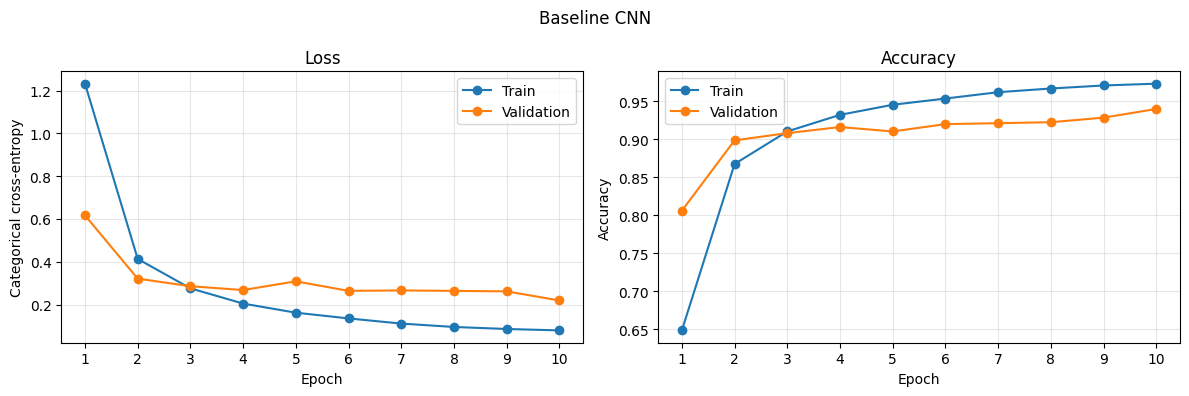

In [22]:
import json
import matplotlib.pyplot as plt

with open("history_baseline.json") as f:
    hist = json.load(f)

epochs = range(1, len(hist["loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(epochs, hist["loss"], marker="o", label="Train")
ax1.plot(epochs, hist["val_loss"], marker="o", label="Validation")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Categorical cross-entropy")
ax1.set_xticks(epochs)
ax1.grid(alpha=0.3)
ax1.legend()

# Accuracy
ax2.plot(epochs, hist["accuracy"], marker="o", label="Train")
ax2.plot(epochs, hist["val_accuracy"], marker="o", label="Validation")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_xticks(epochs)
ax2.grid(alpha=0.3)
ax2.legend()

fig.suptitle("Baseline CNN")
plt.tight_layout()
plt.show()

Per-class evaluation

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in val_ds])
y_pred = np.argmax(model.predict(val_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
cm = confusion_matrix(y_true, y_pred)

340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.713     0.929     0.807       126
                                 Apple___Black_rot      0.976     0.968     0.972       125
                          Apple___Cedar_apple_rust      0.902     0.836     0.868        55
                                   Apple___healthy      0.947     0.875     0.910       329
                               Blueberry___healthy      0.946     0.987     0.966       300
          Cherry_(including_sour)___Powdery_mildew      0.985     0.933     0.958       210
                 Cherry_(including_sour)___healthy      0.939     0.994     0.966       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.781     0.796     0.788       103
                       Corn_(maize)___Common_rust_      1.000     1.000     1.000       239
               Corn_(maize)___Norther

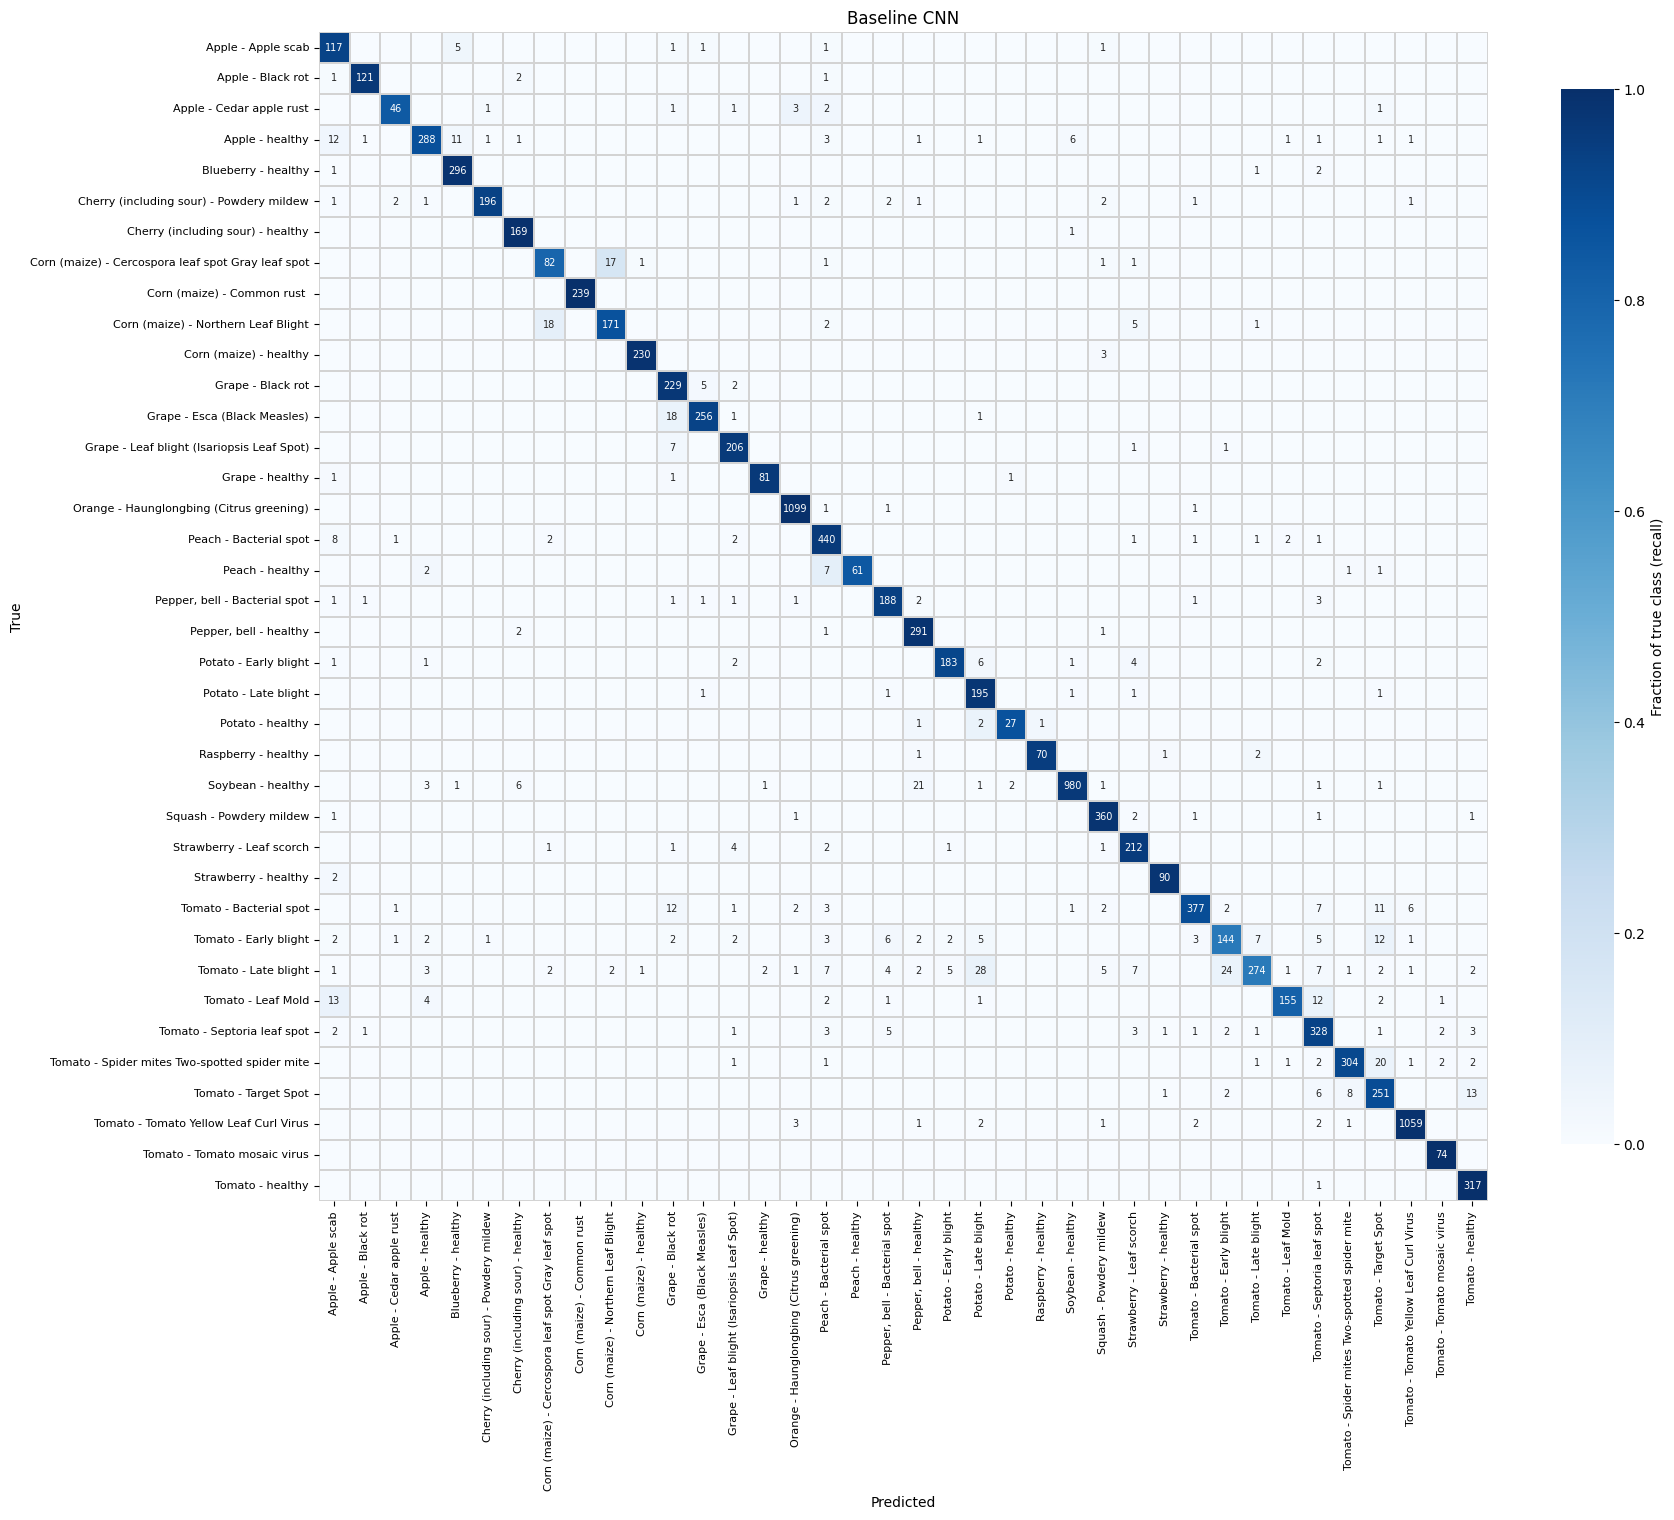

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Colour = fraction of each true class (row-normalised), text = raw counts
cm_norm = cm / cm.sum(axis=1, keepdims=True)
annot = np.where(cm > 0, cm.astype(str), "")
labels = [c.replace("___", " - ").replace("_", " ") for c in class_names]

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm_norm,
    annot=annot,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 7},
    linewidths=0.3,
    linecolor="lightgray",
    square=True,
    cbar_kws={"label": "Fraction of true class (recall)", "shrink": 0.8},
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Baseline CNN")
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
import numpy as np

# Rebuild cm so the cell doesn't depend on a possibly modified copy in memory
cm = confusion_matrix(y_true, y_pred)
support = cm.sum(axis=1)  # images per true class, diagonal included

# Zero the diagonal on a copy so only misclassifications remain
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)

# Indices of the 10 largest off-diagonal cells, largest first
top = np.argsort(off_diag, axis=None)[::-1][:10]
rows, cols = np.unravel_index(top, off_diag.shape)

print(f"{'count':>5}  {'% of true':>9}  {'total':>5}  true -> predicted")
for t, p in zip(rows, cols):
    print(f"{off_diag[t, p]:5d}  {off_diag[t, p] / support[t]:9.1%}  {support[t]:5d}  {class_names[t]} -> {class_names[p]}")



count  % of true  total  true -> predicted
   28       7.3%    382  Tomato___Late_blight -> Potato___Late_blight
   24       6.3%    382  Tomato___Late_blight -> Tomato___Early_blight
   21       2.1%   1018  Soybean___healthy -> Pepper,_bell___healthy
   20       6.0%    335  Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___Target_Spot
   18       6.5%    276  Grape___Esca_(Black_Measles) -> Grape___Black_rot
   18       9.1%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   17      16.5%    103  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight
   13       6.8%    191  Tomato___Leaf_Mold -> Apple___Apple_scab
   13       4.6%    281  Tomato___Target_Spot -> Tomato___healthy
   12       6.0%    200  Tomato___Early_blight -> Tomato___Target_Spot


In [27]:
import json

with open("history_baseline.json") as f:
    hist = json.load(f)

N_EPOCHS = 3
metrics = [k for k in hist if not k.startswith("val_")]

print(f"{'epoch':>5}  {'split':<5}" + "".join(f"{m:>11}" for m in metrics))
for e in range(N_EPOCHS):
    print(f"{e + 1:5d}  {'train':<5}" + "".join(f"{hist[m][e]:11.4f}" for m in metrics))
    print(f"{'':5}  {'val':<5}" + "".join(f"{hist['val_' + m][e]:11.4f}" for m in metrics))


epoch  split   accuracy       loss  precision     recall
    1  train     0.6488     1.2327     0.8573     0.5361
       val       0.8060     0.6168     0.8690     0.7574
    2  train     0.8674     0.4130     0.9088     0.8335
       val       0.8984     0.3210     0.9265     0.8769
    3  train     0.9102     0.2756     0.9317     0.8918
       val       0.9079     0.2854     0.9282     0.8916


In [28]:
# Check keras version
print("Built-in Keras version:", tf.keras.__version__)

Built-in Keras version: 3.10.0


In [31]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

SEED = 42

def make_datasets(seed=SEED):
  train = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=seed,
  )
  val = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
  )
  return prepare(train, training=True), prepare(val)

def build_model(n_classes):
  inputs = Input(shape=(128, 128, 3))
  x = Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same')(inputs)
  x = MaxPooling2D(pool_size=(3, 3))(x)
  x = Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)
  x = Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)
  x = Flatten()(x)
  x = Dense(128, activation='relu')(x)
  outputs = Dense(n_classes, activation='softmax')(x)

  model = Model(inputs=inputs, outputs=outputs)
  return model


In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_per_class(model, ds, title, top_k=10):
  # Labels and predictions (val_ds is unshuffled, so the order matches)
  y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in ds])
  y_pred = np.argmax(model.predict(ds, verbose=0), axis=1)

  # 1. Classification report
  print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

  # 2. Confusion matrix: colour = row-normalised (recall), text = raw counts
  cm = confusion_matrix(y_true, y_pred)
  support = cm.sum(axis=1)
  cm_norm = cm / support[:, None]
  annot = np.where(cm > 0, cm.astype(str), "")
  labels = [c.replace("___", " - ").replace("_", " ") for c in class_names]

  fig, ax = plt.subplots(figsize=(18, 16))
  sns.heatmap(
    cm_norm,
    annot=annot,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=1,
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size": 7},
    linewidths=0.3,
    linecolor="lightgray",
    square=True,
    cbar_kws={"label": "Fraction of true class (recall)", "shrink": 0.8},
    ax=ax,
  )
  ax.set_xlabel("Predicted")
  ax.set_ylabel("True")
  ax.set_title(title)
  plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
  plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
  plt.tight_layout()
  plt.show()

  # 3. Top-k most frequent misclassifications (off-diagonal cells)
  off_diag = cm.copy()
  np.fill_diagonal(off_diag, 0)
  top = np.argsort(off_diag, axis=None)[::-1][:top_k]
  rows, cols = np.unravel_index(top, off_diag.shape)

  print(f"\nTop {top_k} confusions")
  print(f"{'count':>5}  {'% of true':>9}  {'total':>5}  true -> predicted")
  for t, p in zip(rows, cols):
    if off_diag[t, p] == 0:
      break
    print(f"{off_diag[t, p]:5d}  {off_diag[t, p] / support[t]:9.1%}  {support[t]:5d}  "
          f"{class_names[t]} -> {class_names[p]}")

  return cm

In [40]:
import json

def log_history(filename, n_epochs=None):
  with open(filename) as f:
    hist = json.load(f)

  metrics = [k for k in hist if not k.startswith("val_")]
  total = len(hist["loss"])
  n_epochs = total if n_epochs is None else min(n_epochs, total)

  print(f"{filename}  ({total} epochs)")
  print(f"{'epoch':>5}  {'split':<5}" + "".join(f"{m:>11}" for m in metrics))
  for e in range(n_epochs):
    print(f"{e + 1:5d}  {'train':<5}" + "".join(f"{hist[m][e]:11.4f}" for m in metrics))
    if "val_loss" in hist:
      # metrics like epoch_time have no val_ version, so leave that cell blank
      print(f"{'':5}  {'val':<5}" + "".join(
        f"{hist['val_' + m][e]:11.4f}" if f"val_{m}" in hist else f"{'':>11}"
        for m in metrics))

  return hist

Add BatchNormalization

In [34]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Activation
from tensorflow.keras.models import Model

def build_bn_model(n_classes):
  inputs = Input(shape=(128, 128, 3))

  x = Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False)(inputs)
  x = BatchNormalization()(x)
  x = Activation('relu')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)

  x = Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False)(x)
  x = BatchNormalization()(x)
  x = Activation('relu')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)

  x = Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False)(x)
  x = BatchNormalization()(x)
  x = Activation('relu')(x)
  x = MaxPooling2D(pool_size=(3, 3))(x)

  x = Flatten()(x)
  x = Dense(128, activation='relu')(x)
  outputs = Dense(n_classes, activation='softmax')(x)

  model = Model(inputs=inputs, outputs=outputs)
  return model


In [35]:
import os
import json
import numpy as np
import tensorflow as tf
import time

class EpochTimer(tf.keras.callbacks.Callback):
  # Adds "epoch_time" (seconds, train + validation) to the epoch logs,
  # so it ends up in history, the CSV log and the progress bar
  def on_epoch_begin(self, epoch, logs=None):
    self.start = time.time()

  def on_epoch_end(self, epoch, logs=None):
    logs["epoch_time"] = time.time() - self.start

def run_experiment(run_name, build_fn, epochs=30, patience=5, overwrite=False):
  # 0. Protect existing results from being overwritten
  paths = {
    "model":   f"{run_name}.keras",
    "history": f"history_{run_name}.json",
    "csv":     f"history_{run_name}.csv",
  }
  existing = [p for p in paths.values() if os.path.exists(p)]
  if existing:
    if not overwrite:
      raise FileExistsError(
        f"[{run_name}] files already exist: {', '.join(existing)}. "
        f"Use a new run_name, or pass overwrite=True to replace them."
      )
    print(f"[{run_name}] overwrite=True, removing: {', '.join(existing)}")
    for p in existing:
      os.remove(p)   # so a crashed run can't leave old and new files mixed together

  # 1. Seed Python, NumPy and TensorFlow so runs can be reproduced and compared
  tf.keras.backend.clear_session()  # clear any old models from memory
  tf.keras.utils.set_random_seed(SEED)

  # 2. Fresh datasets (new shuffle state for each run)
  train_ds, val_ds = make_datasets()

  # 3. Build and compile the model (new weight init)
  model = build_fn(len(class_names))
  model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',
          tf.keras.metrics.Precision(name='precision'),
          tf.keras.metrics.Recall(name='recall')
          ]
    )
  
  # 4. Callbacks
  callbacks = [
    EpochTimer(),   # must be first, so the callbacks after it see "epoch_time"
    tf.keras.callbacks.EarlyStopping(
      monitor="val_loss",
      patience=patience,
      restore_best_weights=True,
      verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
      paths["model"],
      monitor="val_loss",
      save_best_only=True,
    ),
    tf.keras.callbacks.CSVLogger(paths["csv"]),   # writes a row each epoch, so it survives a crash
  ]

  # 5. Fit
  history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,           # EarlyStopping will stop earlier if no improvement
    callbacks=callbacks,
  )

  # 6. Save the history as JSON
  with open(paths["history"], "w") as f:
    json.dump({k: [float(v) for v in vals]
                 for k, vals in history.history.items()}, f)

  best_epoch = int(np.argmin(history.history["val_loss"])) + 1
  print(f"[{run_name}] epochs run: {len(history.history['loss'])}, best epoch: {best_epoch}")

  return model, history

In [36]:
import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import tensorflow as tf

# Classes to compare across runs (exact names from class_names).
WATCH_PAIRS = [
  ("corn_cerc_to_nlb", "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot", "Corn_(maize)___Northern_Leaf_Blight"),
  ("peach_to_apple", "Peach___healthy", "Apple___healthy"),
  ("tom_early_to_late", "Tomato___Early_blight", "Tomato___Late_blight")
  ]
RESULTS_CSV = "results.csv"

def evaluate_experiment(run_name, top_k=10, n_worst=5, n_epochs=None):
  # 1. Load the best checkpoint saved by run_experiment
  model = tf.keras.models.load_model(f"{run_name}.keras")
  _, val_ds = make_datasets()

  # 2. Evaluate, and check against the best epoch in the history
  results = model.evaluate(val_ds, return_dict=True, verbose=0)
  with open(f"history_{run_name}.json") as f:
    hist = json.load(f)
  best = int(np.argmin(hist["val_loss"]))
  print(f"[{run_name}] best epoch: {best + 1} / {len(hist['loss'])}")
  print(f"{'metric':<10}{'evaluate':>10}{'history':>10}")
  for m, v in results.items():
    print(f"{m:<10}{v:10.4f}{hist['val_' + m][best]:10.4f}")
  print()

  # 3-5. Classification report, confusion matrix, top-k confusions
  cm = evaluate_per_class(model, val_ds, run_name, top_k=top_k)

  # 6. Lowest Recall
  support = cm.sum(axis=1)
  predicted = cm.sum(axis=0)
  tp = np.diag(cm)
  recall = tp / np.maximum(support, 1)
  precision = tp / np.maximum(predicted, 1)
  f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

  idx = list(np.argsort(recall)[:n_worst])
  print(f"\nWatch list (lowest {n_worst} recall)")

  off_diag = cm.copy()
  np.fill_diagonal(off_diag, 0)
  print(f"{'precision':>9}  {'recall':>6}  {'f1':>6}  {'total':>5}  class -> most confused with")
  for i in idx:
    j = int(np.argmax(off_diag[i]))
    confused = f"{class_names[j]} ({off_diag[i, j]})" if off_diag[i, j] > 0 else "-"
    print(f"{precision[i]:9.3f}  {recall[i]:6.3f}  {f1[i]:6.3f}  {support[i]:5d}  "
          f"{class_names[i]} -> {confused}")
  print()

  # 7. History log
  log_history(f"history_{run_name}.json", n_epochs)

  # 8. Summary row in results.csv (replaces the row if this run_name is already there)
  epoch_times = hist.get("epoch_time", [])   # missing for runs trained before EpochTimer
  row = {
    "run_name": run_name,
    "evaluated_at": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "params": model.count_params(),
    "epochs_run": len(hist["loss"]),
    "best_epoch": best + 1,
    "best_val_loss": hist["val_loss"][best],
    "val_accuracy": results["accuracy"],
    "macro_f1": float(f1.mean()),
    "epoch1_sec": epoch_times[0] if epoch_times else np.nan,                           # includes cache filling
    "epoch_sec": float(np.mean(epoch_times[1:])) if len(epoch_times) > 1 else np.nan,  # mean of epochs 2+
  }
  
  support = cm.sum(axis=1)          # images per TRUE class (row sums)

  watch = {}
  print("\nWatch pairs")
  for label, true_name, pred_name in WATCH_PAIRS:
      t = class_names.index(true_name)   # row
      p = class_names.index(pred_name)   # column
      count = int(cm[t, p])
      pct = 100 * count / support[t]

      watch[f"watch_{label}_pct"] = round(float(pct), 1)
      print(f"{label:<20} {count:>4} / {support[t]:<4} = {pct:5.1f}%")
      
  row.update(watch)
  
  df = pd.DataFrame([row])
  if os.path.exists(RESULTS_CSV):
    old = pd.read_csv(RESULTS_CSV)
    old = old[old["run_name"] != run_name]
    if len(old):
      df = pd.concat([old, df], ignore_index=True)
  df.to_csv(RESULTS_CSV, index=False)
  print(f"\nSaved [{run_name}] to {RESULTS_CSV}")

  return model, results, cm

B0 Experiment

In [37]:
run_experiment("B0", build_model)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Epoch 1/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 84s 61ms/step - accuracy: 0.4918 - loss: 1.8620 - precision: 0.7897 - recall: 0.3481 - val_accuracy: 0.8242 - val_loss: 0.5473 - val_precision: 0.8927 - val_recall: 0.7704 - epoch_time: 84.0504
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 104s 77ms/step - accuracy: 0.8460 - loss: 0.4909 - precision: 0.8973 - recall: 0.8012 - val_accuracy: 0.8753 - val_loss: 0.3760 - val_precision: 0.9063 - val_recall: 0.8500 - epoch_time: 104.1723
Epoch 3/30


2026-10-05 21:20:47.300511: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 121s 89ms/step - accuracy: 0.8955 - loss: 0.3230 - precision: 0.9224 - recall: 0.8744 - val_accuracy: 0.9074 - val_loss: 0.2856 - val_precision: 0.9276 - val_recall: 0.8927 - epoch_time: 120.9593
Epoch 4/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 117s 86ms/step - accuracy: 0.9229 - loss: 0.2346 - precision: 0.9399 - recall: 0.9091 - val_accuracy: 0.8862 - val_loss: 0.3674 - val_precision: 0.9035 - val_recall: 0.8742 - epoch_time: 116.6874
Epoch 5/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 118s 87ms/step - accuracy: 0.9361 - loss: 0.1953 - precision: 0.9477 - recall: 0.9259 - val_accuracy: 0.9321 - val_loss: 0.2075 - val_precision: 0.9444 - val_recall: 0.9221 - epoch_time: 118.0537
Epoch 6/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 120s 89ms/step - accuracy: 0.9459 - loss: 0.1588 - precision: 0.9550 - recall: 0.9387 - val_accuracy: 0.9367 - val_loss: 0.1999 - val_precision: 0.9450 - val_recall: 0.9301 - epoch_time: 120.3062
Epoch 7/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 120s 89ms/step - 

(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x11a0852e0>)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.


/Users/myomyataung/workspace/projects/python/-practice-project--plant-disease-classifier/.venv/lib/python3.9/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[B0] best epoch: 11 / 16
metric      evaluate   history
accuracy      0.9498    0.9498
loss          0.1751    0.1751
precision     0.9542    0.9542
recall        0.9471    0.9471

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab      0.851     0.905     0.877       126
                                 Apple___Black_rot      0.967     0.936     0.951       125
                          Apple___Cedar_apple_rust      0.867     0.945     0.904        55
                                   Apple___healthy      0.970     0.900     0.934       329
                               Blueberry___healthy      0.951     0.980     0.966       300
          Cherry_(including_sour)___Powdery_mildew      0.995     0.967     0.981       210
                 Cherry_(including_sour)___healthy      0.960     0.988     0.974       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      0.755     0.777     0.766 

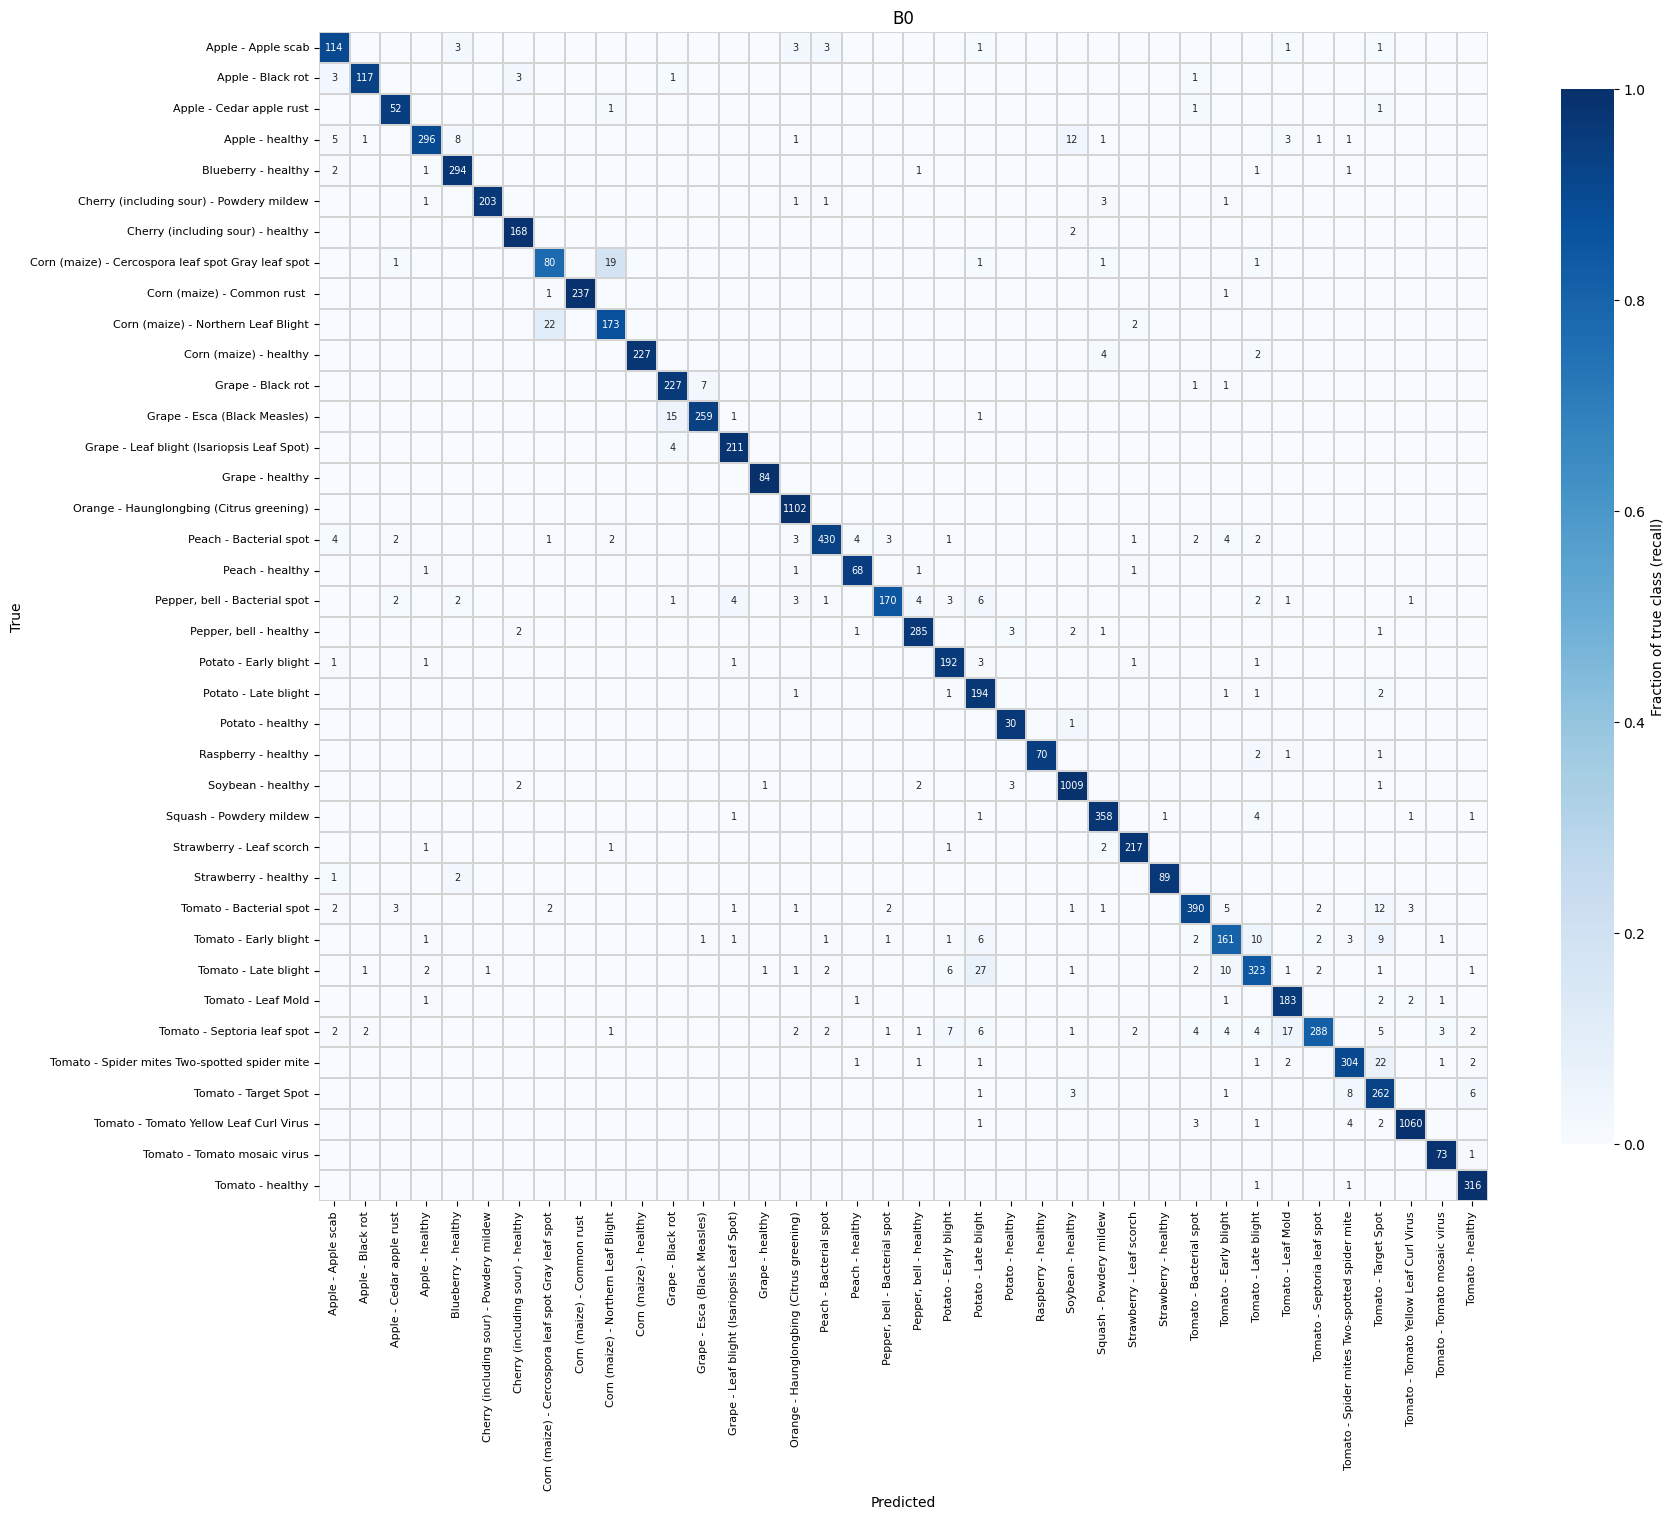


Top 3 confusions
count  % of true  total  true -> predicted
   27       7.1%    382  Tomato___Late_blight -> Potato___Late_blight
   22      11.2%    197  Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   22       6.6%    335  Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___Target_Spot

Watch list (lowest 5 recall)
precision  recall      f1  total  class -> most confused with
    0.755   0.777   0.766    103  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight (19)
    0.847   0.805   0.826    200  Tomato___Early_blight -> Tomato___Late_blight (10)
    0.976   0.814   0.888    354  Tomato___Septoria_leaf_spot -> Tomato___Leaf_Mold (17)
    0.907   0.846   0.875    382  Tomato___Late_blight -> Potato___Late_blight (27)
    0.960   0.850   0.902    200  Pepper,_bell___Bacterial_spot -> Potato___Late_blight (6)

history_B0.json  (16 epochs)
epoch  split   accuracy       loss  precision     recall e

(<Functional name=functional, built=True>,
 {'accuracy': 0.9498204588890076,
  'loss': 0.17506687343120575,
  'precision': 0.9541743993759155,
  'recall': 0.9470582604408264},
 array([[ 114,    0,    0, ...,    0,    0,    0],
        [   3,  117,    0, ...,    0,    0,    0],
        [   0,    0,   52, ...,    0,    0,    0],
        ...,
        [   0,    0,    0, ..., 1060,    0,    0],
        [   0,    0,    0, ...,    0,   73,    1],
        [   0,    0,    0, ...,    0,    0,  316]]))

In [41]:
evaluate_experiment("B0", 3)